# Heart Dataset EDA + Train Test Split



## Step 1: Install libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## Step 2: Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')

## Step 3: Upload CSV

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


## Step 4: Read data

In [4]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Basic EDA

In [5]:
df.shape

(303, 14)

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Target column check

In [11]:
df['target'].value_counts()

,count
target,
1,165
0,138


In [12]:
df['target'].value_counts(normalize=True) * 100

,proportion
target,
1,54.455446
0,45.544554


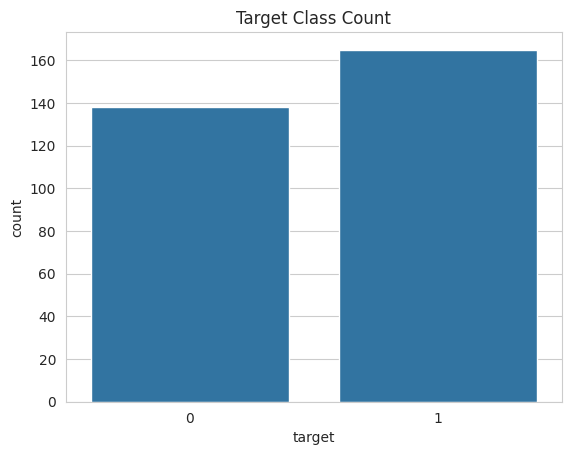

In [13]:
sns.countplot(x='target', data=df)
plt.title('Target Class Count')
plt.show()

## Intermediate EDA: Numeric and Categorical columns

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [15]:
categorical_cols = [c for c in df.columns if c not in ['age','trestbps','chol','thalach','oldpeak','target']]
categorical_cols

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

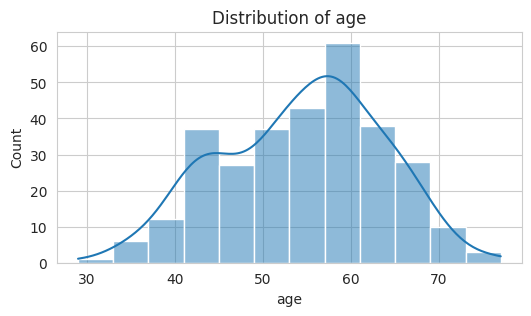

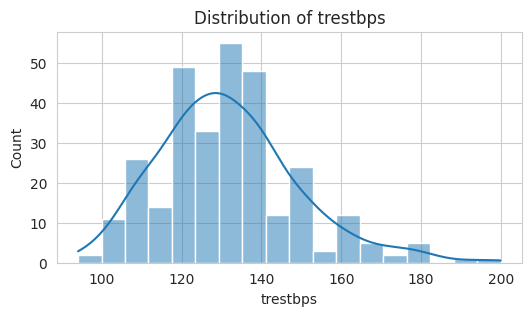

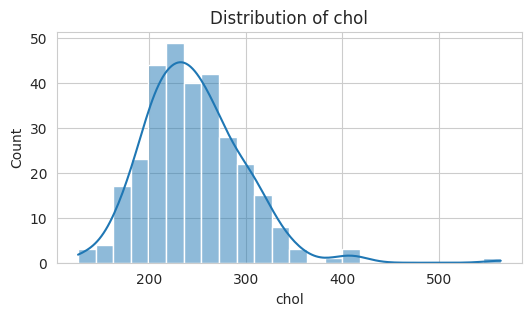

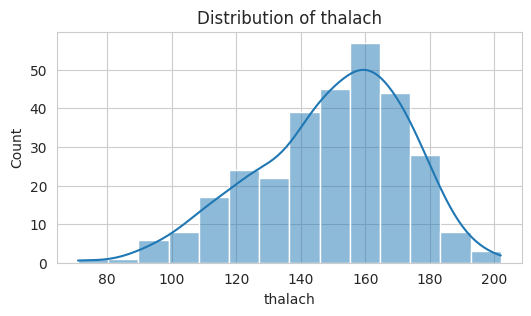

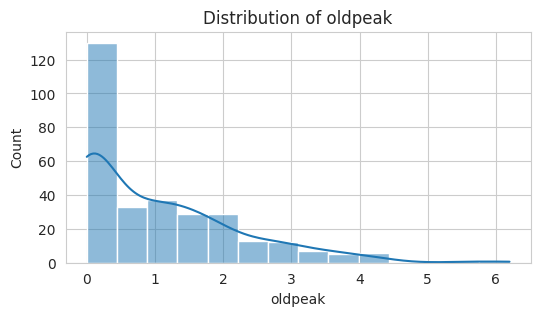

In [16]:
for col in ['age','trestbps','chol','thalach','oldpeak']:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title('Distribution of ' + col)
    plt.show()

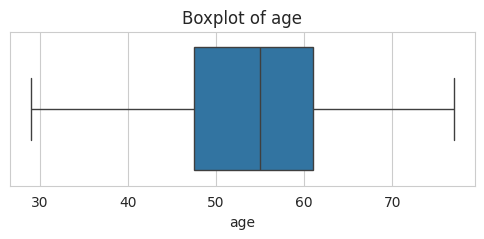

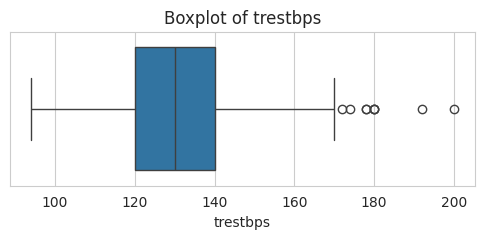

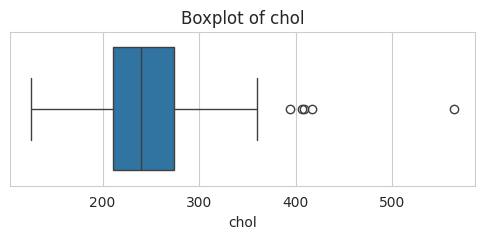

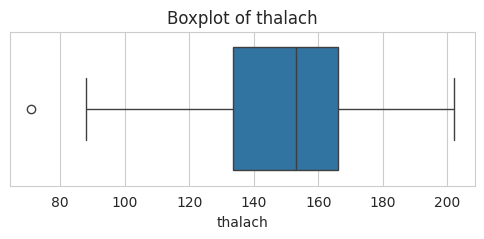

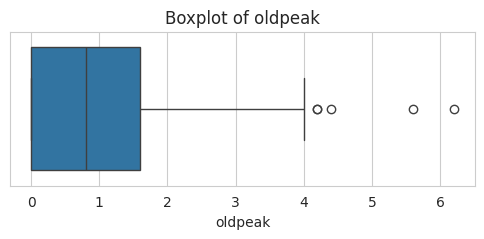

In [17]:
for col in ['age','trestbps','chol','thalach','oldpeak']:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title('Boxplot of ' + col)
    plt.show()

## Advanced EDA

In [18]:
corr = df.corr(numeric_only=True)
corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


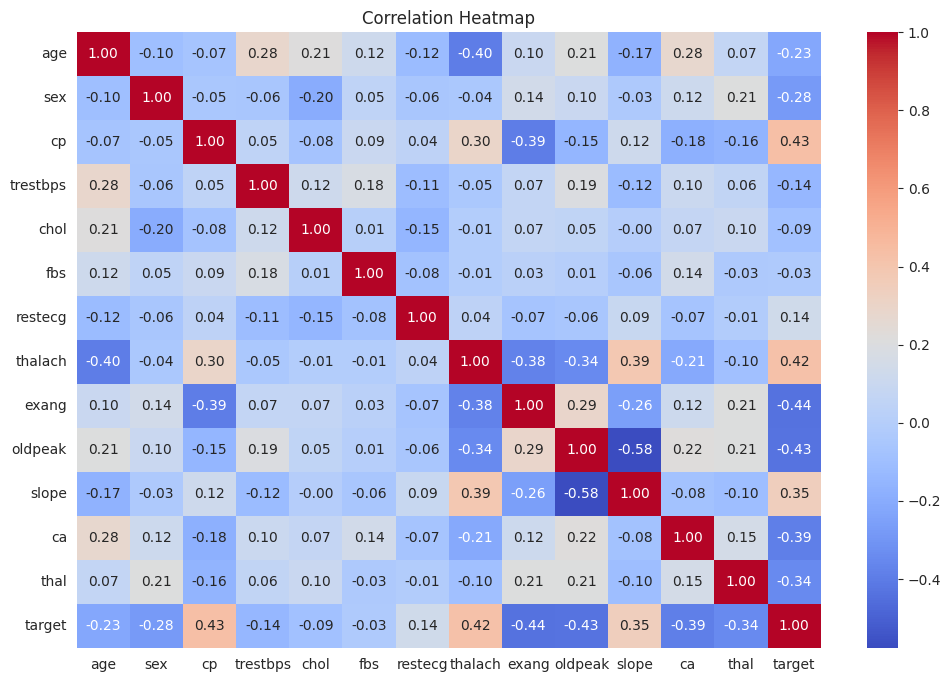

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
corr['target'].sort_values(ascending=False)

,target
target,1.000000
cp,0.433798
thalach,0.421741
slope,0.345877
restecg,0.137230
fbs,-0.028046
chol,-0.085239
trestbps,-0.144931
age,-0.225439
sex,-0.280937


In [21]:
for col in categorical_cols:
    ct = pd.crosstab(df[col], df['target'])
    print('\nColumn:', col)
    print(ct)


Column: sex
target    0   1
sex            
0        24  72
1       114  93

Column: cp
target    0   1
cp             
0       104  39
1         9  41
2        18  69
3         7  16

Column: fbs
target    0    1
fbs             
0       116  142
1        22   23

Column: restecg
target    0   1
restecg        
0        79  68
1        56  96
2         3   1

Column: exang
target   0    1
exang          
0       62  142
1       76   23

Column: slope
target   0    1
slope          
0       12    9
1       91   49
2       35  107

Column: ca
target   0    1
ca             
0       45  130
1       44   21
2       31    7
3       17    3
4        1    4

Column: thal
target   0    1
thal           
0        1    1
1       12    6
2       36  130
3       89   28


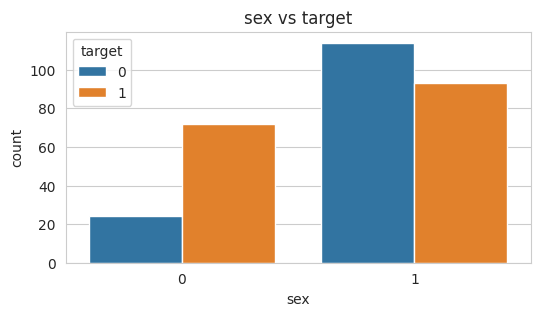

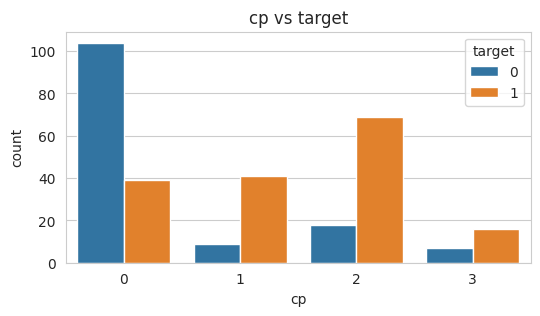

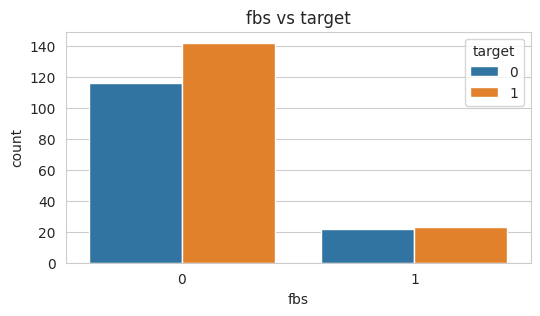

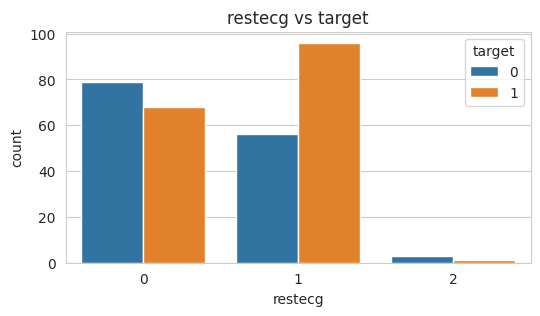

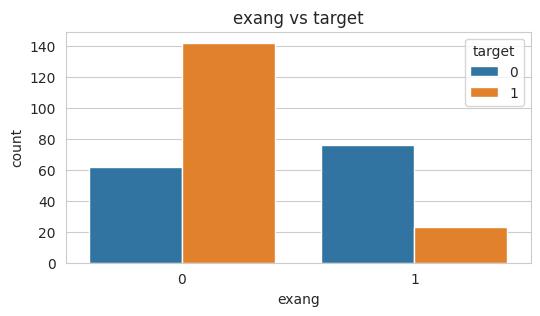

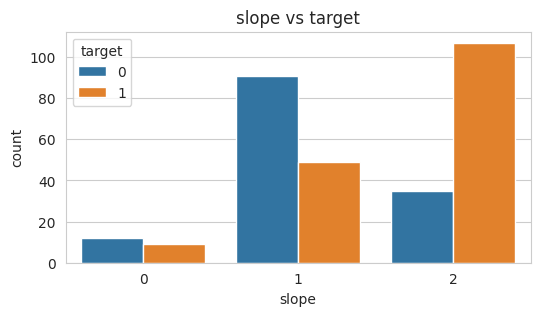

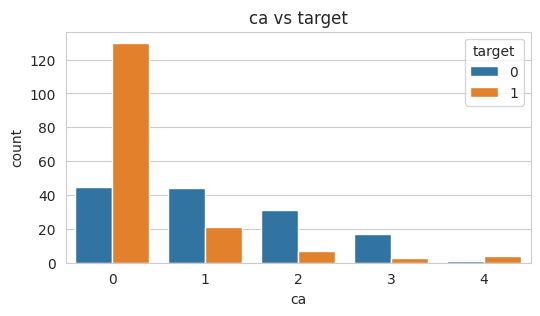

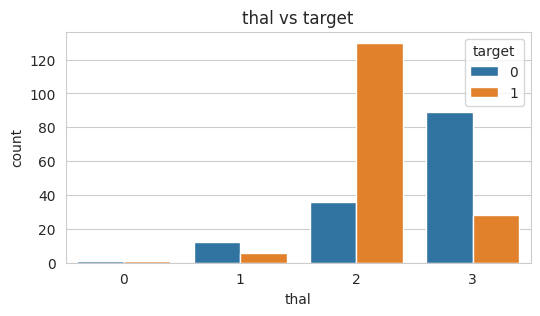

In [22]:
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, hue='target', data=df)
    plt.title(col + ' vs target')
    plt.show()

In [23]:
# Simple outlier count using IQR
for col in ['age','trestbps','chol','thalach','oldpeak']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    outliers = df[(df[col] < low) | (df[col] > high)]
    print(col, 'outliers =', outliers.shape[0])

age outliers = 0
trestbps outliers = 9
chol outliers = 5
thalach outliers = 1
oldpeak outliers = 5


## Train Test Split

In [24]:
X = df.drop('target', axis=1)
y = df['target']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [27]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(target
 1    0.545455
 0    0.454545
 Name: proportion, dtype: float64,
 target
 1    0.540984
 0    0.459016
 Name: proportion, dtype: float64)

## Save split files

In [28]:
import os
os.makedirs('train_test_split', exist_ok=True)

In [29]:
X_train.to_csv('train_test_split/X_train.csv', index=False)
X_test.to_csv('train_test_split/X_test.csv', index=False)
y_train.to_csv('train_test_split/y_train.csv', index=False)
y_test.to_csv('train_test_split/y_test.csv', index=False)

In [30]:
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)
train_df.to_csv('train_test_split/train.csv', index=False)
test_df.to_csv('train_test_split/test.csv', index=False)